# Data Preprocessing for Atlas RAG

> **Experiment status:** This notebook preserves the original preprocessing experiment and its 550/700/90-token artifacts for reproducibility. It is not the production pipeline. The tested FastAPI backend is canonical and uses tokenizer-safe MiniLM chunks with target 220, maximum 240, and overlap 60 tokens; see the repository README and `docs/backend_build/EMBEDDING_CONTEXT_DECISION.md`.

## 1. Introduction

Retrieval-Augmented Generation, or RAG, allows a language model to answer questions using information from a collection of documents.

Instead of training the language model again, the documents are converted into searchable text chunks. When a question is asked, the most relevant chunks are retrieved and supplied to the language model as context.

The complete flow of the project is:

Documents → Text Extraction → Cleaning → Chunking → Embeddings → FAISS Index → Answer Generation

This notebook focuses on the first part of the project. We will discover the files stored in the Atlas60 corpus, extract text from PDF, TXT, and DOCX files, clean the extracted text, study tokenization and stop words, and create overlapping chunks.

### How the Final RAG System Will Work

An embedding converts a piece of text into a numerical vector that represents its meaning. Cosine similarity compares two vectors and tells us how close they are. k-nearest neighbors returns the top-k chunks that are closest to a question. Finally, the generation model uses those retrieved chunks to write an answer.

The preprocessing is successful if the supported documents can be extracted, cleaned, divided into useful chunks, and saved with enough metadata to trace every chunk back to its document and page.

## 2. Dataset Description: The Atlas60 Corpus

The Atlas60 corpus contains documents collected from 10 different domains:

* Technology and Artificial Intelligence
* Healthcare and Biology
* Finance and Economics
* Climate and Environment
* Education
* Law and Public Policy
* History and Culture
* Space and Science
* Cybersecurity
* Business and Management

The collection contains PDF, TXT, and DOCX files. The local data folders are treated as the source of truth.

The domain of each document is derived from its folder, while the file name and file type are read directly from the file. Source URLs, licences, and document titles are not assumed because they have not been supplied as trusted metadata.

In [3]:
%pip install -q pandas matplotlib seaborn pypdf python-docx transformers scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import hashlib
import json
import math
import re
import unicodedata

from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from docx import Document
from IPython.display import display
from pypdf import PdfReader
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from transformers import AutoTokenizer

pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid")

In [5]:
# Locate the project folders
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "atlas60"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "preprocessing"
FIGURE_DIR = ARTIFACT_DIR / "figures"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f"Dataset folder not found: {DATA_DIR}"

print("Project folder:", PROJECT_ROOT)
print("Dataset folder:", DATA_DIR)
print("Artifact folder:", ARTIFACT_DIR)

Project folder: /Users/orbin/Documents/GitHub/atlas-rag
Dataset folder: /Users/orbin/Documents/GitHub/atlas-rag/data/atlas60
Artifact folder: /Users/orbin/Documents/GitHub/atlas-rag/artifacts/preprocessing


## 3. Discovering the Dataset

The local filesystem is the source of truth for this project. Therefore, the documents will be discovered directly from the Atlas60 folders.

Only PDF, TXT, and DOCX files will be selected. Information such as the domain, file name, file type, and file size will be derived from each file.

In [6]:
SUPPORTED_EXTENSIONS = {".pdf", ".txt", ".docx"}

corpus_files = sorted(
    path
    for path in DATA_DIR.rglob("*")
    if path.is_file()
    and path.suffix.lower() in SUPPORTED_EXTENSIONS
)

print("Supported documents found:", len(corpus_files))

Supported documents found: 60


In [7]:
def format_domain(folder_name):
    domain = folder_name.replace("-", " ").capitalize()
    return domain.replace(" ai", " AI")


def generate_document_id(relative_path):
    # A path-based ID stays the same when the notebook is run again
    path_text = relative_path.as_posix().lower()
    path_hash = hashlib.sha256(path_text.encode("utf-8")).hexdigest()[:12]
    return f"doc_{path_hash}"

In [8]:
# Create document records using only the files on disk
ingestion_time = datetime.now(timezone.utc).isoformat()
document_records = []

for path in corpus_files:
    relative_path = path.relative_to(DATA_DIR)

    document_records.append({
        "document_id": generate_document_id(relative_path),
        "file_name": path.name,
        "file_type": path.suffix.replace(".", "").upper(),
        "domain": format_domain(path.parent.name),
        "relative_path": relative_path.as_posix(),
        "resolved_path": str(path.resolve()),
        "size_bytes": path.stat().st_size,
        "ingested_at_utc": ingestion_time
    })

documents_df = pd.DataFrame(document_records)

print("Document inventory shape:", documents_df.shape)
documents_df.head()

Document inventory shape: (60, 8)


,document_id,file_name,file_type,domain,relative_path,resolved_path,size_bytes,ingested_at_utc
0,doc_09549eb0b24f,business_01.txt,TXT,Business and management,business-and-management/business_01.txt,/Users/orbin/Documents/GitHub/atlas-rag/data/atlas60/business-and-management/business_01.txt,9806,2026-07-19T09:31:29.736491+00:00
1,doc_9310ee9043e0,business_02.txt,TXT,Business and management,business-and-management/business_02.txt,/Users/orbin/Documents/GitHub/atlas-rag/data/atlas60/business-and-management/business_02.txt,5342,2026-07-19T09:31:29.736491+00:00
2,doc_5348aab9c91f,business_03.txt,TXT,Business and management,business-and-management/business_03.txt,/Users/orbin/Documents/GitHub/atlas-rag/data/atlas60/business-and-management/business_03.txt,3492,2026-07-19T09:31:29.736491+00:00
3,doc_451c006ce5c5,business_04.txt,TXT,Business and management,business-and-management/business_04.txt,/Users/orbin/Documents/GitHub/atlas-rag/data/atlas60/business-and-management/business_04.txt,1489,2026-07-19T09:31:29.736491+00:00
4,doc_a86f4e958915,business_05.txt,TXT,Business and management,business-and-management/business_05.txt,/Users/orbin/Documents/GitHub/atlas-rag/data/atlas60/business-and-management/business_05.txt,2444,2026-07-19T09:31:29.736491+00:00


In [10]:
domain_counts = documents_df["domain"].value_counts().sort_values(ascending=False)
domain_counts

domain
Business and management    6
Climate and environment    6
Cybersecurity              6
Education                  6
Finance and economics      6
Healthcare and biology     6
History and culture        6
Law and public policy      6
Space and science          6
Technology and AI          6
Name: count, dtype: int64

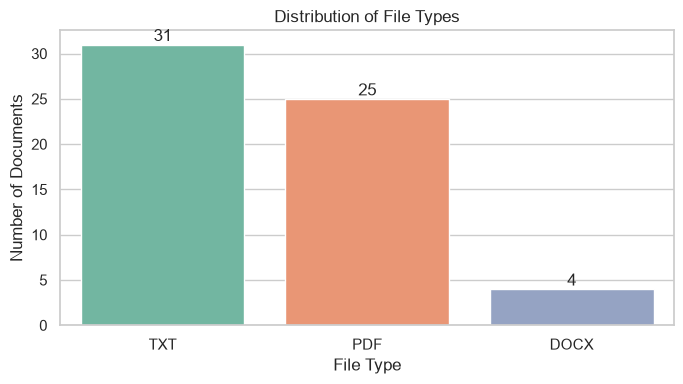

In [12]:
file_type_counts = documents_df["file_type"].value_counts()

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    x=file_type_counts.index,
    y=file_type_counts.values,
    hue=file_type_counts.index,
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of File Types")
plt.xlabel("File Type")
plt.ylabel("Number of Documents")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "documents_by_file_type.png", dpi=200, bbox_inches="tight")
plt.show()

### Dataset Limitation

The notebook can confirm that a file exists, detect its format, and inspect its extracted text. However, the filesystem alone cannot prove the original source URL, licence, or provenance of a document.

These fields will remain optional and will only be added later when trustworthy information is supplied. This limitation does not prevent text preprocessing or retrieval experiments, but it should be mentioned when presenting the project.

## 4. Text Extraction

Different file types require different extraction methods:

* PDF files are read page by page so that page numbers can be preserved.
* TXT files are read as plain UTF-8 text.
* DOCX files are read using their paragraphs and tables.

Keeping page information is important because the final RAG system must show where an answer came from.

In [13]:
def extract_pdf(path):
    reader = PdfReader(str(path))
    return [
        {"page_number": page_number, "raw_text": page.extract_text() or ""}
        for page_number, page in enumerate(reader.pages, start=1)
    ]


def extract_txt(path):
    text = path.read_text(encoding="utf-8", errors="replace")
    return [{"page_number": 1, "raw_text": text}]


def extract_docx(path):
    document = Document(str(path))
    sections = [paragraph.text for paragraph in document.paragraphs if paragraph.text.strip()]

    for table in document.tables:
        for row in table.rows:
            values = [cell.text.strip() for cell in row.cells if cell.text.strip()]
            if values:
                sections.append(" | ".join(values))

    return [{"page_number": 1, "raw_text": "\n\n".join(sections)}]

In [14]:
def extract_document(row):
    path = Path(row.resolved_path)

    if row.file_type == "PDF":
        pages = extract_pdf(path)
    elif row.file_type == "TXT":
        pages = extract_txt(path)
    elif row.file_type == "DOCX":
        pages = extract_docx(path)
    else:
        raise ValueError(f"Unsupported file type: {row.file_type}")

    return [
        {
            "document_id": row.document_id,
            "file_name": row.file_name,
            "domain": row.domain,
            "file_type": row.file_type,
            "relative_path": row.relative_path,
            "page_number": page["page_number"],
            "raw_text": page["raw_text"]
        }
        for page in pages
    ]

In [15]:
# Extract text from every discovered document
extracted_pages = []
extraction_errors = []

for row in documents_df.itertuples(index=False):
    try:
        extracted_pages.extend(extract_document(row))
    except Exception as error:
        extraction_errors.append({
            "document_id": row.document_id,
            "file_name": row.file_name,
            "error": str(error)
        })

print("Documents discovered:", len(documents_df))
print("Pages extracted:", len(extracted_pages))
print("Extraction errors:", len(extraction_errors))

Documents discovered: 60
Pages extracted: 1848
Extraction errors: 0


In [16]:
extraction_summary = (
    pd.DataFrame(extracted_pages)
    .groupby("file_type")
    .agg(
        documents=("document_id", "nunique"),
        pages=("page_number", "count"),
        characters=("raw_text", lambda values: sum(len(value) for value in values))
    )
    .reset_index()
)

extraction_summary

,file_type,documents,pages,characters
0,DOCX,4,4,14564
1,PDF,25,1813,5668921
2,TXT,31,31,239111


In [17]:
# Display one raw text example from each file type
for file_type in ["PDF", "TXT", "DOCX"]:
    example = next((page for page in extracted_pages if page["file_type"] == file_type and page["raw_text"].strip()), None)

    if example:
        print(f"{file_type} Example: {example['file_name']}")
        print(f"Page: {example['page_number']}")
        print(example["raw_text"][:1000])
        print()

PDF Example: climate_06.pdf
Page: 1
A Report of the Intergovernmental Panel on Climate Change
CLIMATE CHANGE 2023
Synthesis Report
Summary for Policymakers

TXT Example: business_01.txt
Page: 1
Write your business plan | U.S. Small Business Administration

Write your business plan

Your business plan is the foundation of your business. Learn how to write a business plan quickly and efficiently with a business plan template.

Content

Business plans help you run your business

A good business plan guides you through each stage of starting and managing your business. You’ll use your business plan as a roadmap for how to structure, run, and grow your new business. It’s a way to think through the key elements of your business. Your research can also help you later in your planning. For example, knowing your

NAICS code

could help you with market analysis, insurance, and taxes.

Business plans can help you get funding or bring on new business partners. Investors want to feel confident they

## 5. Text Cleaning

Extracted text can contain repeated headers, page numbers, broken words, unnecessary line breaks, and extra spaces.

The cleaning process will remove repeated PDF headers and footers, join words that were incorrectly split across lines, normalize Unicode characters, remove empty lines, and reduce repeated spaces.

The text will not be stemmed and stop words will not be removed from the final version. Sentence embeddings work better when the original meaning and word order are preserved.

In [18]:
def find_repeated_margin_lines(document_pages, margin_size=3):
    if len(document_pages) < 3:
        return set()

    line_counts = Counter()

    for page in document_pages:
        lines = [line.strip() for line in page["raw_text"].splitlines() if line.strip()]
        line_counts.update(set(lines[:margin_size] + lines[-margin_size:]))

    minimum_repetitions = max(3, math.ceil(len(document_pages) * 0.30))
    return {
        line for line, count in line_counts.items()
        if count >= minimum_repetitions and len(line) < 200
    }


def remove_repeated_margin_lines(text, repeated_lines):
    return "\n".join(
        line for line in text.splitlines()
        if line.strip() not in repeated_lines
    )

In [19]:
def clean_text(text):
    # Step 1: Normalize characters and line breaks
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\u00ad", "").replace("\u200b", "").replace("\ufeff", "")
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    # Step 2: Join words that were split across lines
    text = re.sub(r"(?<=\w)-\n(?=\w)", "", text)

    # Step 3: Clean paragraphs while keeping natural sentences
    cleaned_paragraphs = []

    for paragraph in re.split(r"\n\s*\n", text):
        lines = []

        for line in paragraph.splitlines():
            line = re.sub(r"[ \t]+", " ", line).strip()
            if line and re.search(r"[A-Za-z0-9]", line):
                lines.append(line)

        if lines:
            cleaned_paragraphs.append(" ".join(lines))

    text = "\n\n".join(cleaned_paragraphs)
    text = re.sub(r" {2,}", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

In [20]:
pages_by_document = defaultdict(list)

for page in extracted_pages:
    pages_by_document[page["document_id"]].append(page)

cleaned_pages = []

for document_id, document_pages in pages_by_document.items():
    document_pages = sorted(document_pages, key=lambda page: page["page_number"])
    repeated_lines = find_repeated_margin_lines(document_pages)

    for page in document_pages:
        source_text = remove_repeated_margin_lines(page["raw_text"], repeated_lines)
        cleaned_pages.append({
            **page,
            "source_text": source_text,
            "cleaned_text": clean_text(source_text),
            "repeated_lines_removed": len(repeated_lines)
        })

print("Cleaned pages:", len(cleaned_pages))
print("Empty pages after cleaning:", sum(not page["cleaned_text"] for page in cleaned_pages))

Cleaned pages: 1848
Empty pages after cleaning: 27


In [21]:
cleaning_example = next(
    page for page in cleaned_pages
    if page["file_type"] == "PDF" and len(page["raw_text"]) > 500
)

print("BEFORE CLEANING")
print("-" * 80)
print(cleaning_example["raw_text"][:1500])

print("\n\nAFTER CLEANING")
print("-" * 80)
print(cleaning_example["cleaned_text"][:1500])

BEFORE CLEANING
--------------------------------------------------------------------------------
CLIMATE CHANGE 2023
Synthesis Report
Summary for Policymakers
Hoesung Lee (Chair), Katherine Calvin (USA), Dipak Dasgupta (India/USA), Gerhard Krinner (France/Germany), Aditi Mukherji 
(India), Peter Thorne (Ireland/United Kingdom), Christopher Trisos (South Africa), José Romero (Switzerland), Paulina Aldunce 
(Chile), Ko Barrett (USA), Gabriel Blanco (Argentina), William W. L. Cheung (Canada), Sarah L. Connors (France/United Kingdom), 
Fatima Denton (The Gambia), Aïda Diongue-Niang (Senegal), David Dodman (Jamaica/United Kingdom/Netherlands), Matthias 
Garschagen (Germany), Oliver Geden (Germany), Bronwyn Hayward (New Zealand), Christopher Jones (United Kingdom), Frank 
Jotzo (Australia), Thelma Krug (Brazil), Rodel Lasco (Philippines), June-Yi Lee (Republic of Korea), Valérie Masson-Delmotte 
(France), Malte Meinshausen (Australia/Germany), Katja Mintenbeck (Germany), Abdalah Mokssit (Mor

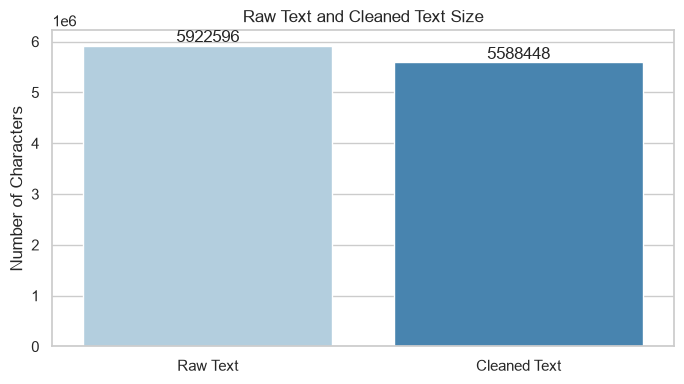

In [22]:
character_totals = pd.DataFrame({
    "Text Version": ["Raw Text", "Cleaned Text"],
    "Characters": [
        sum(len(page["raw_text"]) for page in cleaned_pages),
        sum(len(page["cleaned_text"]) for page in cleaned_pages)
    ]
})

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=character_totals, x="Text Version", y="Characters", hue="Text Version", palette="Blues", legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Raw Text and Cleaned Text Size")
plt.xlabel("")
plt.ylabel("Number of Characters")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "raw_vs_cleaned_characters.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Tokenization and Stop-Word Analysis

Tokenization divides text into smaller units that can be processed by a machine-learning model.

Lowercasing and stop-word removal are useful for studying word frequency. However, they will only be demonstrated here. They will not be applied to the final embedding text because removing common words can change the meaning of a sentence.

In [26]:
# Use part of the corpus for word-frequency analysis
analysis_text = "\n".join(page["cleaned_text"] for page in cleaned_pages)[:500000]
original_words = re.findall(r"\b(?:[A-Z]\.){2,}|\b[A-Za-z]+\b", analysis_text)
lowercase_words = [word.lower() for word in original_words]
stop_words = set(ENGLISH_STOP_WORDS)
content_words = [word for word in lowercase_words if word not in stop_words and len(word) > 2]

print("Original tokens:", original_words[:20])
print("Lowercase tokens:", lowercase_words[:20])
print("Tokens after stop-word filtering:", content_words[:20])
print("\nNumber of word tokens:", len(lowercase_words))
print("Number of stop words:", sum(word in stop_words for word in lowercase_words))
print("Number of content words:", len(content_words))

Original tokens: ['Write', 'your', 'business', 'plan', 'U.S.', 'Small', 'Business', 'Administration', 'Write', 'your', 'business', 'plan', 'Your', 'business', 'plan', 'is', 'the', 'foundation', 'of', 'your']
Lowercase tokens: ['write', 'your', 'business', 'plan', 'u.s.', 'small', 'business', 'administration', 'write', 'your', 'business', 'plan', 'your', 'business', 'plan', 'is', 'the', 'foundation', 'of', 'your']
Tokens after stop-word filtering: ['write', 'business', 'plan', 'u.s.', 'small', 'business', 'administration', 'write', 'business', 'plan', 'business', 'plan', 'foundation', 'business', 'learn', 'write', 'business', 'plan', 'quickly', 'efficiently']

Number of word tokens: 70111
Number of stop words: 25849
Number of content words: 41872


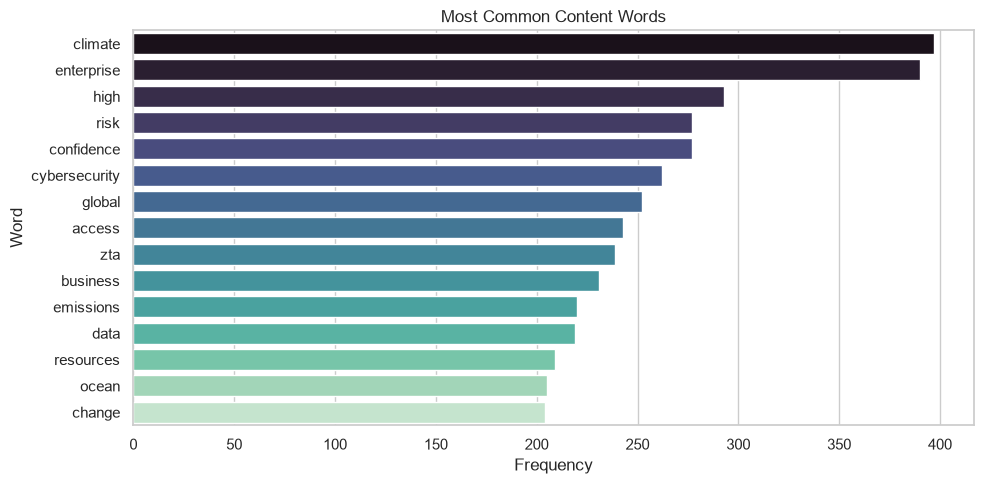

In [27]:
top_content_words = pd.DataFrame(Counter(content_words).most_common(15), columns=["word", "count"])

plt.figure(figsize=(10, 5))
sns.barplot(data=top_content_words, x="count", y="word", hue="word", palette="mako", legend=False)
plt.title("Most Common Content Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "common_content_words.png", dpi=200, bbox_inches="tight")
plt.show()

The stop-word analysis is useful for understanding the vocabulary of the corpus, but the filtered text will not be used for embeddings.

For example, removing words such as “not”, “is”, or “how” may change the meaning of a question or document passage. Therefore, the cleaned natural-language text will be used for chunking and embedding.

## 7. Text Chunking

Embedding an entire document as one vector would make retrieval too broad. Instead, each document is divided into smaller chunks.

The chunking settings used here are:

* Target size: 550 tokens
* Maximum size: 700 tokens
* Overlap: approximately 90 tokens
* Paragraph and sentence boundaries are preferred

The overlap preserves information when a sentence or idea continues near the boundary between two chunks.

In [28]:
# Use the same tokenizer as the planned embedding model
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
TOKENIZER = AutoTokenizer.from_pretrained(EMBEDDING_MODEL)

TARGET_CHUNK_TOKENS = 550
MAX_CHUNK_TOKENS = 700
OVERLAP_TOKENS = 90

def count_tokens(text):
    return len(TOKENIZER.encode(text, add_special_tokens=False, truncation=False))

print("Tokenizer:", EMBEDDING_MODEL)
print("Target chunk size:", TARGET_CHUNK_TOKENS)
print("Maximum chunk size:", MAX_CHUNK_TOKENS)
print("Overlap:", OVERLAP_TOKENS)

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer: sentence-transformers/all-MiniLM-L6-v2
Target chunk size: 550
Maximum chunk size: 700
Overlap: 90


In [29]:
def split_long_unit(raw_text, cleaned_text, max_tokens):
    if count_tokens(cleaned_text) <= max_tokens:
        return [(raw_text, cleaned_text)]

    units = []

    for sentence in re.split(r"(?<=[.!?])\s+", raw_text.strip()):
        cleaned_sentence = clean_text(sentence)

        if not cleaned_sentence:
            continue

        if count_tokens(cleaned_sentence) <= max_tokens:
            units.append((sentence.strip(), cleaned_sentence))
            continue

        token_ids = TOKENIZER.encode(cleaned_sentence, add_special_tokens=False, truncation=False)

        for start in range(0, len(token_ids), max_tokens):
            decoded_text = TOKENIZER.decode(token_ids[start:start + max_tokens], skip_special_tokens=True).strip()
            if decoded_text:
                units.append((decoded_text, decoded_text))

    return units


def create_text_units(source_text):
    paragraphs = [paragraph.strip() for paragraph in re.split(r"\n\s*\n", source_text) if paragraph.strip()]
    units = []

    for paragraph in paragraphs:
        cleaned_paragraph = clean_text(paragraph)
        if cleaned_paragraph:
            units.extend(split_long_unit(paragraph, cleaned_paragraph, MAX_CHUNK_TOKENS))

    return units

In [30]:
def get_overlap_units(units, overlap_tokens):
    overlap = []
    total_tokens = 0

    for unit in reversed(units):
        unit_tokens = count_tokens(unit[1])
        if overlap and total_tokens + unit_tokens > overlap_tokens:
            break
        overlap.insert(0, unit)
        total_tokens += unit_tokens

    return overlap


def chunk_page(page):
    units = create_text_units(page["source_text"])
    page_chunks = []
    current_units = []

    for unit in units:
        current_tokens = count_tokens(" ".join(item[1] for item in current_units))
        unit_tokens = count_tokens(unit[1])

        reached_target = current_tokens >= TARGET_CHUNK_TOKENS
        exceeds_maximum = current_tokens + unit_tokens > MAX_CHUNK_TOKENS

        if current_units and (reached_target or exceeds_maximum):
            page_chunks.append(current_units)
            current_units = get_overlap_units(current_units, OVERLAP_TOKENS)

            overlap_size = count_tokens(" ".join(item[1] for item in current_units))
            if overlap_size + unit_tokens > MAX_CHUNK_TOKENS:
                current_units = []

        current_units.append(unit)

    if current_units:
        page_chunks.append(current_units)

    return page_chunks

In [31]:
# Create chunks and preserve their metadata
cleaned_pages_by_document = defaultdict(list)

for page in cleaned_pages:
    cleaned_pages_by_document[page["document_id"]].append(page)

chunks = []

for document_id, document_pages in cleaned_pages_by_document.items():
    document_pages = sorted(document_pages, key=lambda page: page["page_number"])
    chunk_index = 0

    for page in document_pages:
        for chunk_units in chunk_page(page):
            original_text = "\n\n".join(unit[0] for unit in chunk_units).strip()
            cleaned_text = "\n\n".join(unit[1] for unit in chunk_units).strip()

            chunks.append({
                "chunk_id": f"{document_id}_chunk_{chunk_index:04d}",
                "document_id": document_id,
                "file_name": page["file_name"],
                "domain": page["domain"],
                "file_type": page["file_type"],
                "relative_path": page["relative_path"],
                "page_number": page["page_number"],
                "chunk_index": chunk_index,
                "token_count": count_tokens(cleaned_text),
                "original_text": original_text,
                "cleaned_text": cleaned_text
            })

            chunk_index += 1

chunks_df = pd.DataFrame(chunks)
print("Total chunks created:", len(chunks_df))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (517 > 512). Running this sequence through the model will result in indexing errors


Total chunks created: 2729


In [32]:
chunks_df[[
    "chunk_id",
    "document_id",
    "file_name",
    "domain",
    "page_number",
    "chunk_index",
    "token_count"
]].head(10)

,chunk_id,document_id,file_name,domain,page_number,chunk_index,token_count
0,doc_09549eb0b24f_chunk_0000,doc_09549eb0b24f,business_01.txt,Business and management,1,0,585
1,doc_09549eb0b24f_chunk_0001,doc_09549eb0b24f,business_01.txt,Business and management,1,1,615
2,doc_09549eb0b24f_chunk_0002,doc_09549eb0b24f,business_01.txt,Business and management,1,2,582
3,doc_09549eb0b24f_chunk_0003,doc_09549eb0b24f,business_01.txt,Business and management,1,3,286
4,doc_9310ee9043e0_chunk_0000,doc_9310ee9043e0,business_02.txt,Business and management,1,0,556
5,doc_9310ee9043e0_chunk_0001,doc_9310ee9043e0,business_02.txt,Business and management,1,1,424
6,doc_5348aab9c91f_chunk_0000,doc_5348aab9c91f,business_03.txt,Business and management,1,0,557
7,doc_5348aab9c91f_chunk_0001,doc_5348aab9c91f,business_03.txt,Business and management,1,1,167
8,doc_451c006ce5c5_chunk_0000,doc_451c006ce5c5,business_04.txt,Business and management,1,0,264
9,doc_a86f4e958915_chunk_0000,doc_a86f4e958915,business_05.txt,Business and management,1,0,414


In [33]:
sample_chunk = chunks_df.iloc[0]

print("Chunk ID:", sample_chunk["chunk_id"])
print("Document:", sample_chunk["file_name"])
print("Domain:", sample_chunk["domain"])
print("Page:", sample_chunk["page_number"])
print("Tokens:", sample_chunk["token_count"])
print("-" * 80)
print(sample_chunk["cleaned_text"])

Chunk ID: doc_09549eb0b24f_chunk_0000
Document: business_01.txt
Domain: Business and management
Page: 1
Tokens: 585
--------------------------------------------------------------------------------
Write your business plan | U.S. Small Business Administration

Write your business plan

Your business plan is the foundation of your business. Learn how to write a business plan quickly and efficiently with a business plan template.

Content

Business plans help you run your business

A good business plan guides you through each stage of starting and managing your business. You’ll use your business plan as a roadmap for how to structure, run, and grow your new business. It’s a way to think through the key elements of your business. Your research can also help you later in your planning. For example, knowing your

NAICS code

could help you with market analysis, insurance, and taxes.

Business plans can help you get funding or bring on new business partners. Investors want to feel confident t

count    2729.00
mean      472.81
std       170.56
min         7.00
25%       371.00
50%       551.00
75%       585.00
max       700.00
Name: token_count, dtype: float64

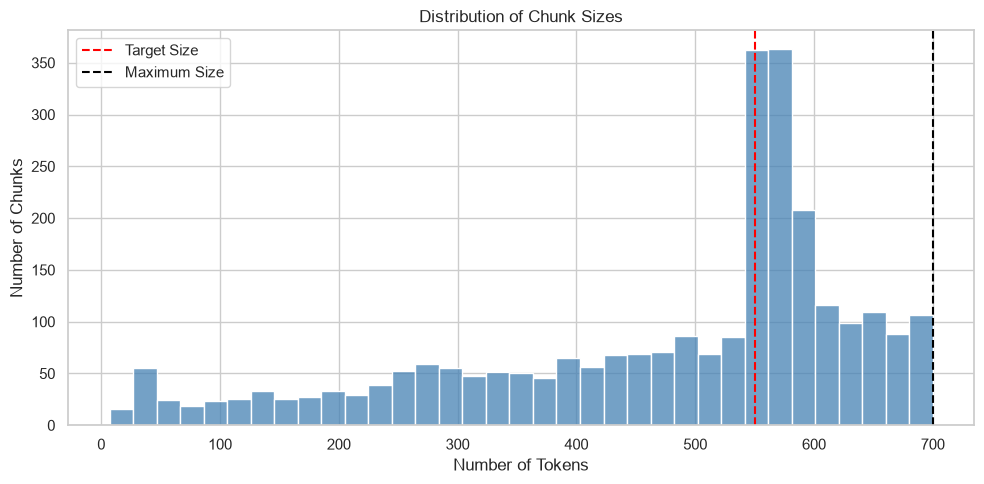

In [34]:
display(chunks_df["token_count"].describe().round(2))

plt.figure(figsize=(10, 5))
sns.histplot(data=chunks_df, x="token_count", bins=35, color="steelblue")
plt.axvline(TARGET_CHUNK_TOKENS, color="red", linestyle="--", label="Target Size")
plt.axvline(MAX_CHUNK_TOKENS, color="black", linestyle="--", label="Maximum Size")
plt.title("Distribution of Chunk Sizes")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Chunks")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "chunk_size_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

Some chunks may be smaller than the target size because PDF page boundaries are preserved. A chunk is not combined with the next page because this would make its page citation unclear.

This is a useful trade-off: slightly smaller chunks are accepted in exchange for more accurate source references.

## 8. Saving the Preprocessing Artifacts

The derived document inventory, extracted pages, cleaned pages, and final chunks will be stored in the preprocessing artifact folder.

JSONL is used for the complete text because it preserves long text and metadata safely. A CSV version of the chunks is also saved for easy inspection.

In [36]:
def save_jsonl(records, output_path):
    with output_path.open("w", encoding="utf-8") as file:
        for record in records:
            file.write(json.dumps(record, ensure_ascii=False, default=str) + "\n")


save_jsonl(extracted_pages, ARTIFACT_DIR / "extracted_pages.jsonl")
save_jsonl(cleaned_pages, ARTIFACT_DIR / "cleaned_pages.jsonl")
save_jsonl(chunks, ARTIFACT_DIR / "chunks.jsonl")

documents_df.to_csv(ARTIFACT_DIR / "document_inventory.csv", index=False)
chunks_df.to_csv(ARTIFACT_DIR / "chunks.csv", index=False)

if extraction_errors:
    pd.DataFrame(extraction_errors).to_csv(ARTIFACT_DIR / "extraction_errors.csv", index=False)

print("Preprocessing artifacts saved.")

Preprocessing artifacts saved.


In [37]:
preprocessing_summary = {
    "documents_discovered": int(len(documents_df)),
    "documents_processed": int(chunks_df["document_id"].nunique()),
    "domains": int(documents_df["domain"].nunique()),
    "extracted_pages": int(len(extracted_pages)),
    "empty_pages_after_cleaning": int(sum(not page["cleaned_text"] for page in cleaned_pages)),
    "total_chunks": int(len(chunks_df)),
    "average_chunk_tokens": round(float(chunks_df["token_count"].mean()), 2),
    "largest_chunk_tokens": int(chunks_df["token_count"].max()),
    "embedding_model": EMBEDDING_MODEL,
    "target_chunk_tokens": TARGET_CHUNK_TOKENS,
    "maximum_chunk_tokens": MAX_CHUNK_TOKENS,
    "overlap_tokens": OVERLAP_TOKENS,
    "extraction_errors": extraction_errors
}

with (ARTIFACT_DIR / "preprocessing_summary.json").open("w", encoding="utf-8") as file:
    json.dump(preprocessing_summary, file, indent=2, ensure_ascii=False)

preprocessing_summary

{'documents_discovered': 60,
 'documents_processed': 60,
 'domains': 10,
 'extracted_pages': 1848,
 'empty_pages_after_cleaning': 27,
 'total_chunks': 2729,
 'average_chunk_tokens': 472.81,
 'largest_chunk_tokens': 700,
 'embedding_model': 'sentence-transformers/all-MiniLM-L6-v2',
 'target_chunk_tokens': 550,
 'maximum_chunk_tokens': 700,
 'overlap_tokens': 90,
 'extraction_errors': []}

## 9. Conclusion

In this notebook, we:

* Discovered the Atlas60 documents directly from the local folders.
* Created document metadata directly from each file and its folder.
* Extracted text from PDF, TXT, and DOCX files.
* Preserved page numbers and document metadata.
* Cleaned extraction noise without removing meaningful language.
* Demonstrated tokenization, lowercasing, and stop-word analysis.
* Created paragraph-aware chunks with overlap.
* Saved the cleaned pages and chunks inside the artifacts folder.

The `chunks.jsonl` artifact will be used in the next notebook to generate sentence-transformer embeddings and build the FAISS index.